## Loading datasets

In [1]:
import pandas as pd

breast_df = pd.read_csv("D:\CodeAlpha\Disease_Prediction_System\datasets\data.csv")
diabetes_df = pd.read_csv("D:\CodeAlpha\Disease_Prediction_System\datasets\diabetes.csv")
heart_df = pd.read_csv("D:\CodeAlpha\Disease_Prediction_System\datasets\heart_disease_health_indicators_BRFSS2015.csv")

print("Breast:", breast_df.shape)
print("Diabetes:", diabetes_df.shape)
print("Heart:", heart_df.shape)

Breast: (569, 33)
Diabetes: (768, 9)
Heart: (253680, 22)


## Pre-processing the datasets

In [2]:
print("Breast Cancer Columns:")
print(breast_df.columns.tolist())

print("\nDiabetes Columns:")
print(diabetes_df.columns.tolist())

print("\nHeart Disease Columns:")
print(heart_df.columns.tolist())

Breast Cancer Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Diabetes Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Heart Disease Columns:
['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'Diff

In [3]:
print("Breast Cancer Missing Values:")
print(heart_df.isnull().sum())

print("\nDiabetes Missing Values:")
print(diabetes_df.isnull().sum())

print("\nHeart Disease Missing Values:")
print(breast_df.isnull().sum())

Breast Cancer Missing Values:
HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Diabetes Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Heart Disease Missing Values:
id                           0
diagnosis     

In [4]:
breast_df = breast_df.drop(["id", "Unnamed: 32"], axis=1)

breast_df["diagnosis"] = breast_df["diagnosis"].map({
    "M": 1,
    "B": 0
})

print(breast_df.shape)
print(breast_df["diagnosis"].unique())

(569, 31)
[1 0]


In [5]:
X_breast = breast_df.drop("diagnosis", axis=1)
y_breast = breast_df["diagnosis"]

X_diabetes = diabetes_df.drop("Outcome", axis=1)
y_diabetes = diabetes_df["Outcome"]

X_heart = heart_df.drop("HeartDiseaseorAttack", axis=1)
y_heart = heart_df["HeartDiseaseorAttack"]

print("Breast:", X_breast.shape, y_breast.shape)
print("Diabetes:", X_diabetes.shape, y_diabetes.shape)
print("Heart:", X_heart.shape, y_heart.shape)

Breast: (569, 30) (569,)
Diabetes: (768, 8) (768,)
Heart: (253680, 21) (253680,)


## Splitting

In [6]:
from sklearn.model_selection import train_test_split

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_breast, y_breast, test_size=0.2, random_state=42
)

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42
)

print(Xb_train.shape, Xb_test.shape)
print(Xd_train.shape, Xd_test.shape)
print(Xh_train.shape, Xh_test.shape)

(455, 30) (114, 30)
(614, 8) (154, 8)
(202944, 21) (50736, 21)


## Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

scaler_breast = StandardScaler()
Xb_train = scaler_breast.fit_transform(Xb_train)
Xb_test = scaler_breast.transform(Xb_test)

scaler_diabetes = StandardScaler()
Xd_train = scaler_diabetes.fit_transform(Xd_train)
Xd_test = scaler_diabetes.transform(Xd_test)

scaler_heart = StandardScaler()
Xh_train = scaler_heart.fit_transform(Xh_train)
Xh_test = scaler_heart.transform(Xh_test)

print("Scaling completed")

Scaling completed


## Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_breast = LogisticRegression(max_iter=1000)
lr_breast.fit(Xb_train, yb_train)

lr_diabetes = LogisticRegression(max_iter=1000)
lr_diabetes.fit(Xd_train, yd_train)

lr_heart = LogisticRegression(max_iter=1000)
lr_heart.fit(Xh_train, yh_train)

pred_breast = lr_breast.predict(Xb_test)
pred_diabetes = lr_diabetes.predict(Xd_test)
pred_heart = lr_heart.predict(Xh_test)

print("Breast Cancer Accuracy:",
      accuracy_score(yb_test, pred_breast))

print("Diabetes Accuracy:",
      accuracy_score(yd_test, pred_diabetes))

print("Heart Disease Accuracy:",
      accuracy_score(yh_test, pred_heart))

Breast Cancer Accuracy: 0.9736842105263158
Diabetes Accuracy: 0.7532467532467533
Heart Disease Accuracy: 0.9084673604541155


## Random forest

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_breast = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_diabetes = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_heart = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_breast.fit(Xb_train, yb_train)
rf_diabetes.fit(Xd_train, yd_train)
rf_heart.fit(Xh_train, yh_train)

pred_breast = rf_breast.predict(Xb_test)
pred_diabetes = rf_diabetes.predict(Xd_test)
pred_heart = rf_heart.predict(Xh_test)

print("Breast Cancer Accuracy:",
      accuracy_score(yb_test, pred_breast))

print("Diabetes Accuracy:",
      accuracy_score(yd_test, pred_diabetes))

print("Heart Disease Accuracy:",
      accuracy_score(yh_test, pred_heart))

Breast Cancer Accuracy: 0.9649122807017544
Diabetes Accuracy: 0.7207792207792207
Heart Disease Accuracy: 0.9034413434247871


## SVM

In [10]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

heart_sample = heart_df.sample(
    n=10000,
    random_state=42
)

X_heart_sample = heart_sample.drop(
    "HeartDiseaseorAttack",
    axis=1
)

y_heart_sample = heart_sample[
    "HeartDiseaseorAttack"
]

Xh_train_svm, Xh_test_svm, yh_train_svm, yh_test_svm = train_test_split(
    X_heart_sample,
    y_heart_sample,
    test_size=0.2,
    random_state=42
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Xh_train_svm = scaler.fit_transform(Xh_train_svm)
Xh_test_svm = scaler.transform(Xh_test_svm)

svm_breast = SVC()
svm_breast.fit(Xb_train, yb_train)

svm_diabetes = SVC()
svm_diabetes.fit(Xd_train, yd_train)

svm_heart = SVC()
svm_heart.fit(Xh_train_svm, yh_train_svm)

print(
    "Breast:",
    accuracy_score(
        yb_test,
        svm_breast.predict(Xb_test)
    )
)

print(
    "Diabetes:",
    accuracy_score(
        yd_test,
        svm_diabetes.predict(Xd_test)
    )
)

print(
    "Heart:",
    accuracy_score(
        yh_test_svm,
        svm_heart.predict(Xh_test_svm)
    )
)

Breast: 0.9824561403508771
Diabetes: 0.7337662337662337
Heart: 0.901


In [18]:
import joblib

joblib.dump(scaler_breast, "../models/breast_scaler.pkl")
joblib.dump(scaler_diabetes, "../models/diabetes_scaler.pkl")
joblib.dump(scaler_heart, "../models/heart_scaler.pkl")

print("Scalers saved successfully")

Scalers saved successfully


## XGBoost

In [14]:
from xgboost import XGBClassifier
print("XGBoost Installed")

XGBoost Installed


In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_breast = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_diabetes = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_heart = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_breast.fit(Xb_train, yb_train)
xgb_diabetes.fit(Xd_train, yd_train)
xgb_heart.fit(Xh_train, yh_train)

print(
    "Breast:",
    accuracy_score(
        yb_test,
        xgb_breast.predict(Xb_test)
    )
)

print(
    "Diabetes:",
    accuracy_score(
        yd_test,
        xgb_diabetes.predict(Xd_test)
    )
)

print(
    "Heart:",
    accuracy_score(
        yh_test,
        xgb_heart.predict(Xh_test)
    )
)

Breast: 0.956140350877193
Diabetes: 0.7077922077922078
Heart: 0.906929990539262


## Accuracy Comparison Chart

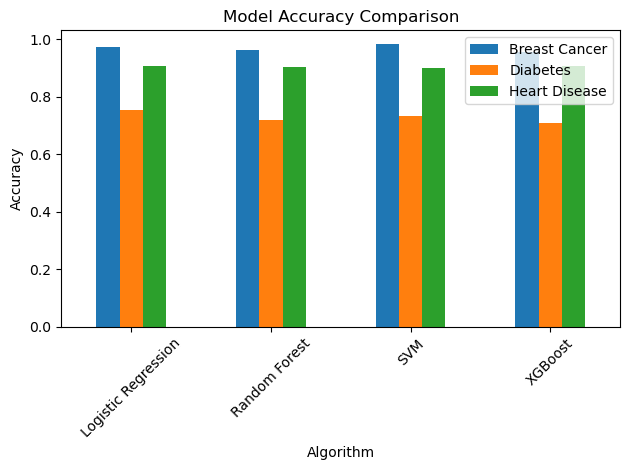

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Algorithm": ["Logistic Regression", "Random Forest", "SVM", "XGBoost"],
    "Breast Cancer": [0.9737, 0.9649, 0.9825, 0.9561],
    "Diabetes": [0.7532, 0.7208, 0.7338, 0.7078],
    "Heart Disease": [0.9085, 0.9034, 0.9010, 0.9069]
})

results.set_index("Algorithm").plot(kind="bar")

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [17]:
import joblib

joblib.dump(svm_breast, "../models/breast_cancer_model.pkl")
joblib.dump(lr_diabetes, "../models/diabetes_model.pkl")
joblib.dump(lr_heart, "../models/heart_disease_model.pkl")

print("Models saved successfully")

Models saved successfully


In [20]:
import joblib

breast_model = joblib.load("../models/breast_cancer_model.pkl")
diabetes_model = joblib.load("../models/diabetes_model.pkl")
heart_model = joblib.load("../models/heart_disease_model.pkl")

print(type(breast_model).__name__)
print(type(diabetes_model).__name__)
print(type(heart_model).__name__)

SVC
LogisticRegression
LogisticRegression
